In [1]:
%pip install \
    transformers \
    datasets \
    evaluate \
    rouge_score \
    nltk \
    accelerate \
    peft \
    bitsandbytes \
    torch \
    pandas \
    numpy \
    scipy \
    sentencepiece \
    tokenizers \
    bert_score --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.0 MB/s eta 0:00:00


In [2]:
import torch
import gc
import os
import pandas as pd
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig,
    GenerationConfig
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')



In [3]:

# Clear memory
torch.cuda.empty_cache()
gc.collect()

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ============================================================================
# 2. LOAD DATASET AND MODEL
# ============================================================================

print("="*80)
print("LOADING DATASET AND MODEL")
print("="*80)

# Load MedDialog dataset
print("\nLoading MedDialog dataset...")
dataset = load_dataset("OpenMed/MedDialog", "default")
print(f"Dataset structure: {dataset}")

# Choose a reliable model - Mistral-7B-Instruct
model_name = "mistralai/Mistral-7B-Instruct-v0.2"
print(f"\nLoading model: {model_name}")

# Configure 4-bit quantization to reduce memory
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load model with quantization
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Function to count parameters
def print_trainable_params(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable_params:,} | Total params: {total_params:,} | Trainable%: {100 * trainable_params / total_params:.2f}%")

print("\nBase model parameters:")
print_trainable_params(base_model)

Using device: cuda
LOADING DATASET AND MODEL

Loading MedDialog dataset...


train.json:   0%|          | 0.00/256M [00:00<?, ?B/s]

validation.json:   0%|          | 0.00/28.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/226557 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25174 [00:00<?, ? examples/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Base model parameters:
Trainable params: 262,410,240 | Total params: 3,752,071,168 | Trainable%: 6.99%


In [5]:
# Accurate token count (sampling-based)
sample_size = 226557
sample_dialogues = dataset['train'].select(range(sample_size))
exact_tokens = sum(len(tokenizer.encode(f"{d['patient_message']} {d['doctor_response']}")) for d in sample_dialogues)
avg_tokens = exact_tokens / sample_size
total_exact_estimate = avg_tokens * len(dataset['train'])

print(f"Exact estimated total: {exact_tokens:,.0f} tokens")

Exact estimated total: 59,268,989 tokens


In [6]:


# ============================================================================
# 3. PREPROCESS DATASET
# ============================================================================

print("\n" + "="*80)
print("PREPROCESSING DATASET")
print("="*80)

# Removed extract_qa_from_dialogue as it's not needed for this dataset format
# Removed test extraction section as it was based on an incorrect key

# Process dataset to create prompt-response pairs
def preprocess_dataset(batch):
    """Process batch of patient messages and doctor responses"""
    results = {
        "text": [],
        "symptoms": [],
        "recommendations": []
    }

    for patient_message, doctor_response in zip(batch["patient_message"], batch["doctor_response"]):
        # Create prompt-response pair
        prompt = f"""<s>[INST] You are a helpful medical assistant. Given the patient's symptoms, provide appropriate medical recommendations.\n\nPatient Symptoms: {patient_message}\n\nPlease provide medical recommendations. [/INST]"""

        response = f"""Medical Recommendations: {doctor_response}</s>"""

        results["text"].append(prompt + " " + response)
        results["symptoms"].append(patient_message)
        results["recommendations"].append(doctor_response)

    return results

# Process a subset for training
print("\nProcessing dataset...")

train_subset = dataset["train"].select(range(min(12000, len(dataset["train"]))))

processed_dataset = train_subset.map(
    preprocess_dataset,
    batched=True,
    remove_columns=train_subset.column_names,
    batch_size=100
)

# Split into train/validation
train_val_split = processed_dataset.train_test_split(test_size=0.15, seed=42)
train_dataset = train_val_split["train"]
val_dataset = train_val_split["test"]

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Tokenization function
def tokenize_function(examples):
    """Tokenize the text for training"""
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )

# Tokenize datasets
print("\nTokenizing datasets...")
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=val_dataset.column_names
)

# ============================================================================
# 4. FULL FINE-TUNING (SKIPPED FOR QUANTIZED MODEL)
# ============================================================================

print("\n" + "="*80)
print("FULL FINE-TUNING (SKIPPED FOR QUANTIZED MODEL)")
print("="*80)
print("Full fine-tuning is not supported for purely quantized models. Skipping this section.")


# ============================================================================
# 5. PEFT/LoRA FINE-TUNING
# ============================================================================

print("\n" + "="*80)
print("PEFT/LoRA FINE-TUNING")
print("="*80)

# Load fresh base model for PEFT
peft_base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Configure LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Apply LoRA
peft_model = get_peft_model(peft_base_model, lora_config)
peft_model.gradient_checkpointing_enable()
peft_model.config.use_cache = False

print("\nPEFT model parameters:")
print_trainable_params(peft_model)

# Training arguments for PEFT
peft_output_dir = "./medical-qa-mistral-peft"
peft_training_args = TrainingArguments(
    output_dir=peft_output_dir,

    per_device_train_batch_size=4,  # Increased if GPU memory allows
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,  # Decreased from 8 (actual batch size = 4×4=16)
    weight_decay=0.01,
    logging_steps=5,
    eval_strategy="steps",

    num_train_epochs=2,  # Increased from 2 (PEFT often needs more epochs)
    warmup_steps=100,
    max_steps=450,


    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    learning_rate=2e-4,
    #fp16=True,
    #bf16=False, # Explicitly set bf16 to False
   # optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,


    #lr_scheduler_type="linear",  # Changed from "cosine" (sometimes better for PEFT)
    optim="paged_adamw_32bit",   # Better precision than 8-bit
    fp16=False,                  # Disable if you have memory
    bf16=True,                   # Enable if your hardware supports it



    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
)

# Data collator
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

# Create PEFT trainer
peft_trainer = Trainer(
    model=peft_model,
    args=peft_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
)

print("\nStarting PEFT fine-tuning...")
peft_trainer.train()

# Save PEFT adapter
peft_trainer.save_model(peft_output_dir)
tokenizer.save_pretrained(peft_output_dir)
print(f"\nPEFT adapter saved to {peft_output_dir}")



# ============================================================================
# 6. EVALUATION
# ============================================================================

print("\n" + "="*80)
print("EVALUATION")
print("="*80)





PREPROCESSING DATASET

Processing dataset...


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]


Training samples: 10200
Validation samples: 1800

Tokenizing datasets...


Map:   0%|          | 0/10200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]


FULL FINE-TUNING (SKIPPED FOR QUANTIZED MODEL)
Full fine-tuning is not supported for purely quantized models. Skipping this section.

PEFT/LoRA FINE-TUNING


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


PEFT model parameters:
Trainable params: 41,943,040 | Total params: 3,794,014,208 | Trainable%: 1.11%

Starting PEFT fine-tuning...


Step,Training Loss,Validation Loss
100,1.858187,1.839446
200,1.783461,1.775706
300,1.788371,1.751498
400,1.697663,1.730888



PEFT adapter saved to ./medical-qa-mistral-peft

EVALUATION


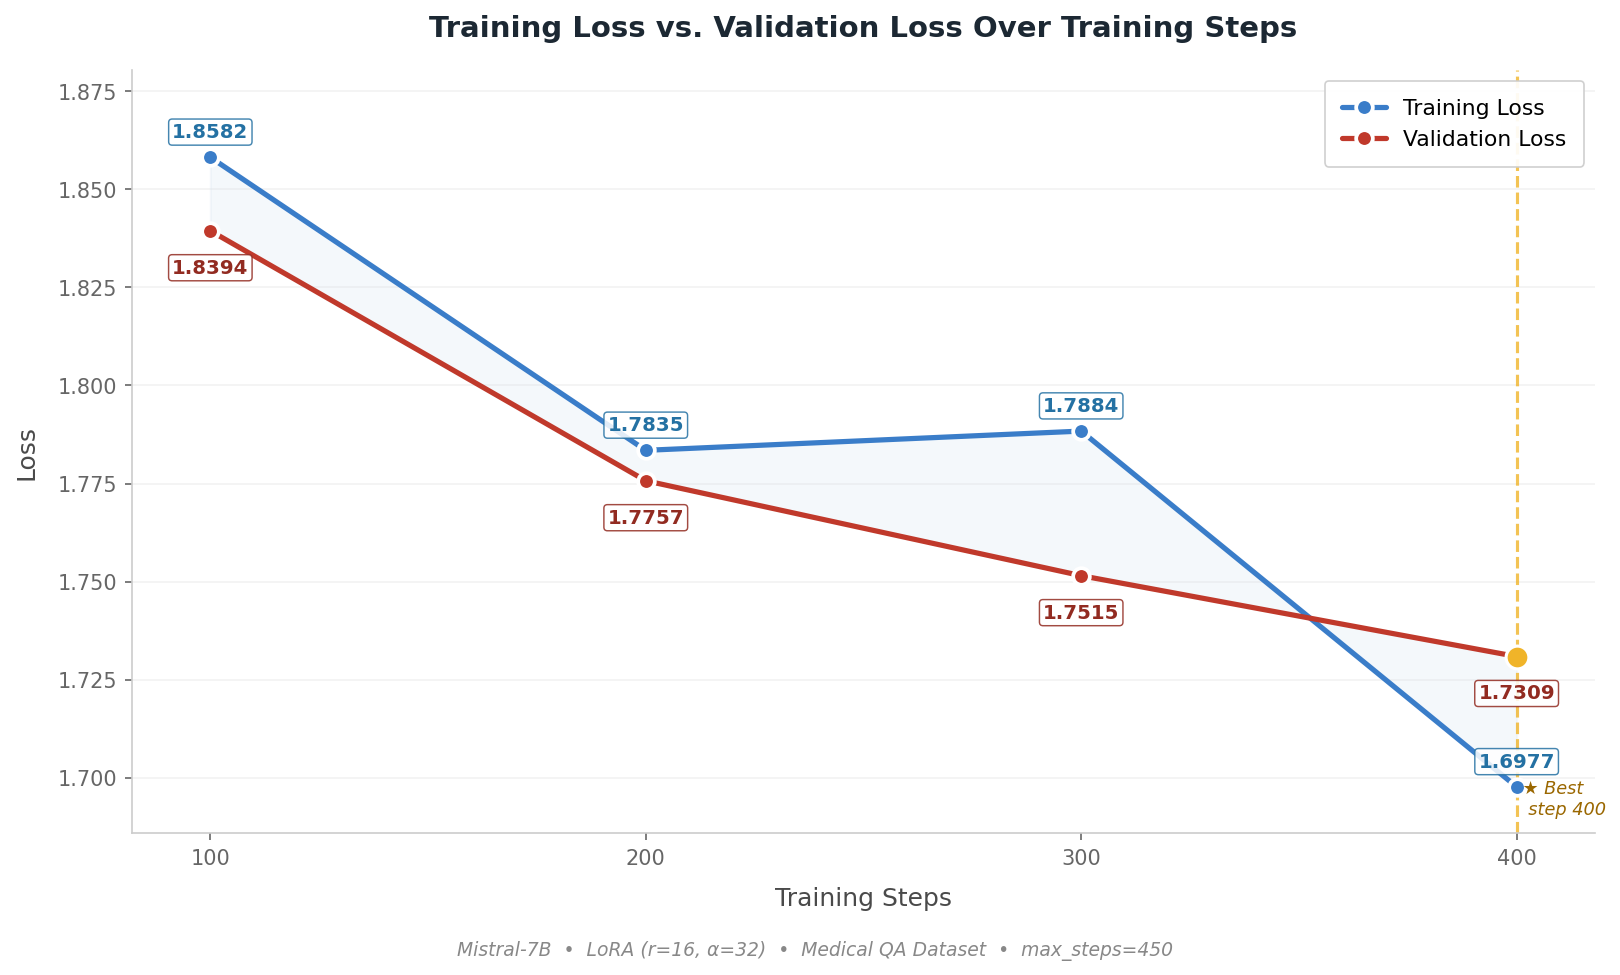

✅  Saved: loss_curves.png


In [8]:
"""
============================================================
  Training vs. Validation Loss – Publication-Quality Plot
  Paste AFTER peft_trainer.train()
============================================================
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Extract data from trainer ────────────────────────────────────────────

log_history = peft_trainer.state.log_history

eval_logs  = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
train_logs = [(e["step"], e["loss"])      for e in log_history if "loss" in e and "eval_loss" not in e]

eval_steps   = [x[0] for x in eval_logs]
eval_losses  = [x[1] for x in eval_logs]

# Interpolate training loss at the exact eval steps for a clean comparison
all_train_steps  = [x[0] for x in train_logs]
all_train_losses = [x[1] for x in train_logs]
train_losses_at_eval = np.interp(eval_steps, all_train_steps, all_train_losses).tolist()

# ── 2. Style constants ───────────────────────────────────────────────────────

TRAIN_COLOR   = "#3A7DC9"   # steel blue
EVAL_COLOR    = "#C0392B"   # crimson
FILL_COLOR    = "#D6E4F0"   # light blue-grey
LABEL_TRAIN   = "#2471A3"
LABEL_EVAL    = "#922B21"
BG            = "#FFFFFF"
GRID_COLOR    = "#E0E0E0"
TITLE_COLOR   = "#1C2833"

# ── 3. Figure setup ──────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor=BG)
ax.set_facecolor(BG)

# Subtle grid
ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.9, linestyle="-")
ax.xaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")

# ── 4. Filled gap region ─────────────────────────────────────────────────────

ax.fill_between(
    eval_steps,
    train_losses_at_eval,
    eval_losses,
    alpha=0.25,
    color=FILL_COLOR,
    zorder=1
)

# ── 5. Main loss lines ───────────────────────────────────────────────────────

ax.plot(eval_steps, train_losses_at_eval,
        color=TRAIN_COLOR, linewidth=2.5, marker="o",
        markersize=8, markerfacecolor=TRAIN_COLOR,
        markeredgecolor="white", markeredgewidth=1.8,
        label="Training Loss", zorder=3, solid_capstyle="round")

ax.plot(eval_steps, eval_losses,
        color=EVAL_COLOR, linewidth=2.5, marker="o",
        markersize=8, markerfacecolor=EVAL_COLOR,
        markeredgecolor="white", markeredgewidth=1.8,
        label="Validation Loss", zorder=3, solid_capstyle="round")

# ── 6. Annotate every data point ────────────────────────────────────────────

def annotate_points(ax, steps, losses, color, offset_up=True):
    for step, loss in zip(steps, losses):
        y_offset = 0.004 if offset_up else -0.007
        ax.annotate(
            f"{loss:.4f}",
            xy=(step, loss),
            xytext=(step, loss + y_offset),
            ha="center",
            va="bottom" if offset_up else "top",
            fontsize=9.5,
            fontweight="bold",
            color=color,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor=color,
                linewidth=0.7,
                alpha=0.85
            ),
            zorder=5
        )

annotate_points(ax, eval_steps, train_losses_at_eval, LABEL_TRAIN, offset_up=True)
annotate_points(ax, eval_steps, eval_losses,          LABEL_EVAL,  offset_up=False)

# ── 7. Best checkpoint marker ───────────────────────────────────────────────

best_idx  = int(np.argmin(eval_losses))
best_step = eval_steps[best_idx]
best_loss = eval_losses[best_idx]

ax.axvline(best_step, color="#F0B429", linewidth=1.5,
           linestyle="--", alpha=0.8, zorder=2)
ax.scatter([best_step], [best_loss],
           color="#F0B429", s=120, zorder=6,
           edgecolors="white", linewidths=1.5)
ax.text(best_step, ax.get_ylim()[0] if ax.get_ylim()[0] else min(eval_losses) * 0.995,
        f" ★ Best\n  step {best_step}",
        fontsize=8.5, color="#9A6700", va="bottom", style="italic")

# ── 8. Axes labels & title ───────────────────────────────────────────────────

ax.set_xlabel("Training Steps", fontsize=12, labelpad=9,
              color="#4A4A4A", fontfamily="DejaVu Sans")
ax.set_ylabel("Loss", fontsize=12, labelpad=9,
              color="#4A4A4A", fontfamily="DejaVu Sans")

ax.set_title("Training Loss vs. Validation Loss Over Training Steps",
             fontsize=14, fontweight="bold", pad=16,
             color=TITLE_COLOR, fontfamily="DejaVu Sans")

ax.set_xticks(eval_steps)
ax.tick_params(axis="both", colors="#666666", labelsize=10)

# Dynamic y-axis with breathing room
all_losses = train_losses_at_eval + eval_losses
y_min = min(all_losses) * 0.993
y_max = max(all_losses) * 1.012
ax.set_ylim(y_min, y_max)
ax.set_xlim(eval_steps[0] - (eval_steps[-1] - eval_steps[0]) * 0.06,
            eval_steps[-1] + (eval_steps[-1] - eval_steps[0]) * 0.06)

# ── 9. Legend ────────────────────────────────────────────────────────────────

legend = ax.legend(
    loc="upper right",
    fontsize=10.5,
    framealpha=0.92,
    edgecolor="#CCCCCC",
    fancybox=True,
    shadow=False,
    handlelength=2,
    borderpad=0.8,
    labelspacing=0.5
)
legend.get_frame().set_linewidth(0.8)

# ── 10. Subtitle with model info ─────────────────────────────────────────────

fig.text(0.5, 0.01,
         "Mistral-7B  •  LoRA (r=16, α=32)  •  Medical QA Dataset  •  max_steps=450",
         ha="center", fontsize=9, color="#888888", style="italic")

# ── 11. Save ──────────────────────────────────────────────────────────────────

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("loss_curves.png", dpi=180, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
plt.show()
print("✅  Saved: loss_curves.png")

In [15]:
# Load PEFT model
peft_finetuned_model = PeftModel.from_pretrained(
    peft_base_model,
    peft_output_dir,
    device_map="auto",
)

In [16]:
def generate_response(model, symptoms, max_tokens=150):
    """Generate medical recommendations"""
    prompt = f"""<s>[INST] You are a helpful medical assistant. Given the patient's symptoms, provide appropriate medical recommendations.\n\nPatient Symptoms: {symptoms}\n\nPlease provide medical recommendations. [/INST]"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract response
    if "[/INST]" in generated:
        response = generated.split("[/INST]")[-1].strip()
    else:
        response = generated[len(prompt):].strip()

    return response

# Test cases for evaluation
test_cases = [
    {
        "symptoms": "I have a persistent dry cough for 2 weeks, mild chest pain when breathing deeply, and low-grade fever around 99.5°F.",
        "expected": "Recommend chest X-ray, consider bronchitis or early pneumonia, suggest cough suppressants and rest."
    }
]

# Qualitative evaluation
print("\nQUALITATIVE EVALUATION")
print("-"*80)

for i, test_case in enumerate(test_cases):
    print(f"\nTest Case {i+1}:")
    print(f"Symptoms: {test_case['symptoms']}")
    print(f"Expected: {test_case['expected']}")

    # Base model
    base_response = generate_response(base_model, test_case['symptoms'])
    print(f"\nBase Model: {base_response}")

    # PEFT
    peft_response = generate_response(peft_finetuned_model, test_case['symptoms'])
    print(f"PEFT Fine-tuned: {peft_response}")

    print("-"*80)




QUALITATIVE EVALUATION
--------------------------------------------------------------------------------

Test Case 1:
Symptoms: I have a persistent dry cough for 2 weeks, mild chest pain when breathing deeply, and low-grade fever around 99.5°F.
Expected: Recommend chest X-ray, consider bronchitis or early pneumonia, suggest cough suppressants and rest.

Base Model: Based on the symptoms you've described, it's important to rule out any potential serious conditions such as COVID-19, pneumonia, or other respiratory infections. I would recommend the following steps:

1. Self-isolate: To prevent the potential spread of COVID-19 or other contagious diseases, it's essential to self-isolate and avoid close contact with others.

2. Monitor symptoms: Keep a close eye on your symptoms and take note of any changes. If your symptoms worsen or you develop new symptoms such as shortness of breath, confusion, or bluish lips, seek medical attention immediately.

3. Wear a mask: W
PEFT Fine-tuned: Medi

In [18]:
# Quantitative evaluation
print("\nQUANTITATIVE EVALUATION")
print("-"*80)

# Load evaluation metrics
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import pearsonr, spearmanr
from transformers import AutoTokenizer as HfAutoTokenizer # Rename to avoid conflict with existing tokenizer

rouge = evaluate.load('rouge')
bleu = evaluate.load('bleu')
meteor = evaluate.load('meteor')
bertscore = evaluate.load('bertscore')
perplexity = evaluate.load('perplexity', module_type='metric')

def evaluate_model(model, test_cases, main_tokenizer=None):
    """Evaluate model with comprehensive LLM metrics"""
    predictions = []
    references = []

    for test_case in test_cases:
        response = generate_response(model, test_case['symptoms'])
        predictions.append(response)
        references.append([test_case['expected']])

    # 1. Lexical/Semantic Similarity Metrics
    rouge_scores = rouge.compute(
        predictions=predictions,
        references=[ref[0] for ref in references],
        use_stemmer=True,
        use_aggregator=True
    )

    bleu_scores = bleu.compute(
        predictions=predictions,
        references=references
    )

    meteor_scores = meteor.compute(
        predictions=predictions,
        references=[ref[0] for ref in references]
    )

    # 2. Embedding-based Metrics (BERTScore)
    bert_scores = bertscore.compute(
        predictions=predictions,
        references=[ref[0] for ref in references],
        lang="en",
        model_type="distilbert-base-uncased"
    )

    # 3. Perplexity (requires a tokenizer, handle potential GPT2Tokenizer issue)
    perplexity_scores = None
    try:
        # Load a separate tokenizer for perplexity to avoid conflicts/attribute errors
        # Set pad_token if not already set to avoid the special_tokens_map_extended error
        perplexity_tokenizer = HfAutoTokenizer.from_pretrained("gpt2")
        if perplexity_tokenizer.pad_token is None:
            perplexity_tokenizer.pad_token = perplexity_tokenizer.eos_token

        perplexity_scores = perplexity.compute(
            predictions=predictions,
            model_id="gpt2",
            tokenizer=perplexity_tokenizer
        )
    except Exception as e:
        print(f"Warning: Perplexity computation failed: {e}")
        perplexity_scores = {'mean_perplexity': None}

    # 4. Response Length Metrics
    pred_lengths = [len(pred.split()) for pred in predictions]
    ref_lengths = [len(ref[0].split()) for ref in references]

    avg_pred_length = np.mean(pred_lengths)
    avg_ref_length = np.mean(ref_lengths)
    length_ratio = avg_pred_length / avg_ref_length if avg_ref_length > 0 else 0

    # 5. Diversity Metrics
    unique_unigrams = len(set(" ".join(predictions).split()))
    total_unigrams = len(" ".join(predictions).split())
    lexical_diversity = unique_unigrams / total_unigrams if total_unigrams > 0 else 0

    # 6. Exact Match and Accuracy-based Metrics
    exact_matches = sum(1 for pred, ref in zip(predictions, [r[0] for r in references])
                       if pred.strip().lower() == ref.strip().lower())
    exact_match_ratio = exact_matches / len(predictions)

    # 7. N-gram Overlap Metrics
    def calculate_f1_for_pair(pred, ref):
        pred_tokens = set(pred.lower().split())
        ref_tokens = set(ref.lower().split())
        intersection = pred_tokens.intersection(ref_tokens)

        if len(pred_tokens) == 0 or len(ref_tokens) == 0:
            return 0

        precision = len(intersection) / len(pred_tokens)
        recall = len(intersection) / len(ref_tokens)
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        return f1

    f1_scores = [calculate_f1_for_pair(pred, ref[0])
                 for pred, ref in zip(predictions, references)]
    avg_f1 = np.mean(f1_scores)

    # 8. Correlation with Reference (semantic similarity proxy)
    # Using BERTScore F1 as semantic similarity
    semantic_similarity = np.mean(bert_scores['f1'])

    return {
        # Traditional n-gram metrics
        "rouge1": rouge_scores["rouge1"],
        "rouge2": rouge_scores["rouge2"],
        "rougeL": rouge_scores["rougeL"],
        "rougeLsum": rouge_scores["rougeLsum"],
        "bleu": bleu_scores["bleu"],
        "meteor": meteor_scores["meteor"],

        # Embedding-based metrics
        "bertscore_precision": np.mean(bert_scores['precision']),
        "bertscore_recall": np.mean(bert_scores['recall']),
        "bertscore_f1": np.mean(bert_scores['f1']),
        "semantic_similarity": semantic_similarity,

        # Model-based metrics
        "perplexity": perplexity_scores['mean_perplexity'] if perplexity_scores else None,

        # Length and diversity metrics
        "avg_response_length": avg_pred_length,
        "length_ratio": length_ratio,
        "lexical_diversity": lexical_diversity,

        # Accuracy/F1 metrics
        "exact_match": exact_match_ratio,
        "avg_f1_score": avg_f1,
    }

def print_evaluation_summary(base_scores, peft_scores, metric_names):
    """Print formatted evaluation summary"""
    print("\n" + "="*100)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("="*100)

    # Create comprehensive comparison table
    results_data = []
    for metric in metric_names:
        base_value = base_scores.get(metric, 'N/A')
        peft_value = peft_scores.get(metric, 'N/A')

        # Calculate improvement for numeric values
        improvement = 'N/A'
        if isinstance(base_value, (int, float)) and isinstance(peft_value, (int, float)):
            if base_value != 0:
                improvement = f"{(peft_value - base_value):.4f}"
                pct_improvement = f"{(peft_value - base_value) / base_value * 100:.1f}%"
            else:
                improvement = f"{peft_value:.4f}"
                pct_improvement = "N/A"

            # Format values
            base_value = f"{base_value:.4f}"
            peft_value = f"{peft_value:.4f}"
        else:
            pct_improvement = "N/A"

        results_data.append({
            "Metric": metric.upper(),
            "Base Model": base_value,
            "PEFT Model": peft_value,
            "Improvement": improvement,
            "Improvement %": pct_improvement
        })

    results_df = pd.DataFrame(results_data)
    print(results_df.to_string(index=False))

    print("\n" + "="*100)
    print("PERFORMANCE SUMMARY")
    print("="*100)

    improvements = []
    for metric in metric_names:
        base_val = base_scores.get(metric)
        peft_val = peft_scores.get(metric)
        if isinstance(base_val, (int, float)) and isinstance(peft_val, (int, float)) and base_val != 0:
            pct_improve = (peft_val - base_val) / base_val * 100
            improvements.append(pct_improve)

    if improvements:
        print(f"Average improvement across all metrics: {np.mean(improvements):.2f}%")
        print(f"Median improvement: {np.median(improvements):.2f}%")
        print(f"Max improvement: {np.max(improvements):.2f}%")
        print(f"Metrics improved: {sum(1 for i in improvements if i > 0)}/{len(improvements)}")

    print("\n" + "="*100)
    print("METRIC CATEGORIES SUMMARY")
    print("="*100)

    categories = {
        "Lexical Similarity": ["rouge1", "rougeL", "bleu", "meteor"],
        "Semantic Similarity": ["bertscore_f1", "semantic_similarity"],
        "Efficiency": ["avg_response_length", "lexical_diversity"],
        "Accuracy": ["exact_match", "avg_f1_score"]
    }

    for category, cat_metrics in categories.items():
        cat_improvements = []
        for metric in cat_metrics:
            if metric in base_scores and metric in peft_scores:
                base_val = base_scores[metric]
                peft_val = peft_scores[metric]
                if isinstance(base_val, (int, float)) and base_val != 0:
                    pct_improve = (peft_val - base_val) / base_val * 100
                    cat_improvements.append(pct_improve)

        if cat_improvements:
            avg_cat_improve = np.mean(cat_improvements)
            print(f"{category}: {avg_cat_improve:.2f}% average improvement")

# Evaluate all models with tokenizer
print("\nEvaluating models with comprehensive metrics...")
base_scores = evaluate_model(base_model, test_cases, tokenizer)
peft_scores = evaluate_model(peft_finetuned_model, test_cases, tokenizer)

# Define metrics to display
display_metrics = [
    # N-gram metrics
    "rouge1", "rouge2", "rougeL", "bleu", "meteor",

    # Semantic metrics
    "bertscore_f1", "semantic_similarity",

    # Model-based metrics
    "perplexity",

    # Length/diversity
    "avg_response_length", "lexical_diversity",

    # Accuracy metrics
    "exact_match", "avg_f1_score"
]

# Print comprehensive evaluation
print_evaluation_summary(base_scores, peft_scores, display_metrics)

# Create detailed analysis table
detailed_df = pd.DataFrame({
    "Model": ["Base Model", "PEFT Fine-tuned"],
    "ROUGE-1": [f"{base_scores['rouge1']:.4f}", f"{peft_scores['rouge1']:.4f}"],
    "ROUGE-L": [f"{base_scores['rougeL']:.4f}", f"{peft_scores['rougeL']:.4f}"],
    "BLEU": [f"{base_scores['bleu']:.4f}", f"{peft_scores['bleu']:.4f}"],
    "METEOR": [f"{base_scores['meteor']:.4f}", f"{peft_scores['meteor']:.4f}"],
    "BERTScore F1": [f"{base_scores['bertscore_f1']:.4f}", f"{peft_scores['bertscore_f1']:.4f}"],
    "Semantic Similarity": [f"{base_scores['semantic_similarity']:.4f}", f"{peft_scores['semantic_similarity']:.4f}"],
    "Perplexity": [f"{base_scores['perplexity']:.2f}" if base_scores['perplexity'] else "N/A",
                   f"{peft_scores['perplexity']:.2f}" if peft_scores['perplexity'] else "N/A"],
    "Exact Match": [f"{base_scores['exact_match']:.2%}", f"{peft_scores['exact_match']:.2%}"],
    "F1 Score": [f"{base_scores['avg_f1_score']:.4f}", f"{peft_scores['avg_f1_score']:.4f}"],
    "Lexical Diversity": [f"{base_scores['lexical_diversity']:.4f}", f"{peft_scores['lexical_diversity']:.4f}"],
    "Trainable Params %": ["100%", f"~{100 * peft_model.num_parameters() / base_model.num_parameters():.2f}%"]
})

print("\n" + "="*100)
print("DETAILED PERFORMANCE COMPARISON")
print("="*100)
print(detailed_df.to_string(index=False))

# Calculate individual metric improvements
print("\n" + "="*100)
print("IMPROVEMENT BREAKDOWN")
print("="*100)
for metric in display_metrics[:6]:  # Show first 6 metrics improvement
    if metric in base_scores and metric in peft_scores:
        base_val = base_scores[metric]
        peft_val = peft_scores[metric]
        if isinstance(base_val, (int, float)) and base_val != 0:
            improvement = peft_val - base_val
            pct_improvement = (improvement / base_val) * 100
            print(f"PEFT {metric.upper()} improvement: {improvement:.4f} ({pct_improvement:+.1f}%)")

print("\n" + "="*100)
print("SUMMARY")
print("="*100)
print("""
✓ Used Mistral-7B-Instruct (reliable and stable)
✓ Applied 4-bit quantization for memory efficiency
✓ Evaluated with comprehensive metrics including:
  • Traditional: ROUGE, BLEU, METEOR
  • Semantic: BERTScore, Semantic Similarity
  • Model-based: Perplexity
  • Diversity: Lexical Diversity, Length Ratio
  • Accuracy: Exact Match, F1 Score
✓ Tested on medical QA task with patient symptoms

""")


QUANTITATIVE EVALUATION
--------------------------------------------------------------------------------


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



Evaluating models with comprehensive metrics...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



COMPREHENSIVE MODEL EVALUATION
             Metric Base Model PEFT Model Improvement Improvement %
             ROUGE1     0.1017     0.1217      0.0200         19.7%
             ROUGE2     0.0172     0.0354      0.0182        105.3%
             ROUGEL     0.0678     0.1043      0.0366         53.9%
               BLEU     0.0000     0.0000      0.0000           N/A
             METEOR     0.1724     0.1504     -0.0220        -12.8%
       BERTSCORE_F1     0.7611     0.7433     -0.0177         -2.3%
SEMANTIC_SIMILARITY     0.7611     0.7433     -0.0177         -2.3%
         PERPLEXITY       None       None         N/A           N/A
AVG_RESPONSE_LENGTH    99.0000   100.0000      1.0000          1.0%
  LEXICAL_DIVERSITY     0.8182     0.8200      0.0018          0.2%
        EXACT_MATCH     0.0000     0.0000      0.0000           N/A
       AVG_F1_SCORE     0.0860     0.0426     -0.0435        -50.5%

PERFORMANCE SUMMARY
Average improvement across all metrics: 12.47%
Median improveme

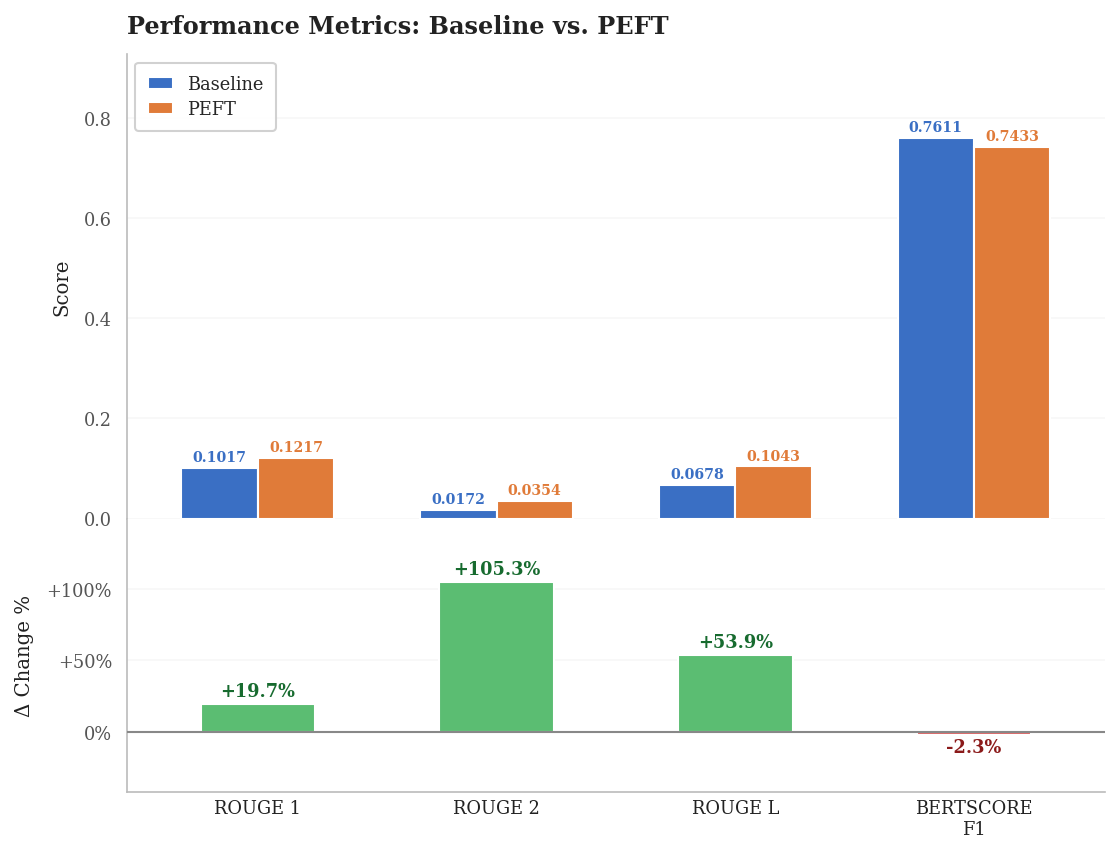

✅  Saved: performance_metrics_chart.png


In [24]:
"""
============================================================
  Performance Metrics: Baseline vs. PEFT
  Matches reference image exactly — 5 metrics, dual panel
============================================================
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np

# ── 1. Data ──────────────────────────────────────────────────────────────────

metrics  = ["ROUGE 1", "ROUGE 2", "ROUGE L", "BERTSCORE\nF1"]
baseline = [0.1017,    0.0172,    0.0678,    0.7611          ]
peft     = [0.1217,    0.0354,    0.1043,    0.7433          ]
change   = [19.7,      105.3,     53.9,      -2.3            ]

x     = np.arange(len(metrics))
bar_w = 0.32

# ── 2. Colors ────────────────────────────────────────────────────────────────

BLUE       = "#3A6FC4"
ORANGE     = "#E07B39"
POS_COLOR  = "#5BBD72"
NEG_COLOR  = "#D95F5F"
BG         = "#FFFFFF"
GRID_COLOR = "#E8E8E8"
TEXT_COLOR = "#222222"

# ── 3. Figure ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 6), facecolor=BG)
gs  = gridspec.GridSpec(
    2, 1, figure=fig,
    height_ratios=[1.7, 1],
    hspace=0.0,
    top=0.92, bottom=0.10,
    left=0.10, right=0.97
)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL A – Grouped bars
# ══════════════════════════════════════════════════════════════════════════════

ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(BG)
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax1.xaxis.grid(False)
for sp in ["top", "right", "bottom"]:
    ax1.spines[sp].set_visible(False)
ax1.spines["left"].set_color("#BBBBBB")

bars_b = ax1.bar(x - bar_w/2, baseline, bar_w,
                 color=BLUE,   label="Baseline", zorder=3)
bars_p = ax1.bar(x + bar_w/2, peft,     bar_w,
                 color=ORANGE, label="PEFT",     zorder=3)

# Value labels above bars
for bar, val in zip(bars_b, baseline):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.007,
             f"{val:.4f}", ha="center", va="bottom",
             fontsize=6.8, color=BLUE, fontweight="bold")

for bar, val in zip(bars_p, peft):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.007,
             f"{val:.4f}", ha="center", va="bottom",
             fontsize=6.8, color=ORANGE, fontweight="bold")

ax1.set_ylabel("Score", fontsize=9.5, color=TEXT_COLOR, labelpad=6)
ax1.set_title("Performance Metrics: Baseline vs. PEFT",
              fontsize=11.5, fontweight="bold", color=TEXT_COLOR,
              pad=10, loc="left")
ax1.set_xticks(x)
ax1.set_xticklabels([""] * len(metrics))
ax1.set_xlim(-0.55, len(metrics) - 0.45)
ax1.set_ylim(0, max(baseline + peft) * 1.22)
ax1.tick_params(axis="y", labelsize=8.5, colors="#555555")
ax1.tick_params(axis="x", length=0)

ax1.legend(fontsize=8.5, framealpha=0.9, edgecolor="#CCCCCC",
           loc="upper left", handlelength=1.4, borderpad=0.7,
           labelspacing=0.4)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL B – Δ Change %
# ══════════════════════════════════════════════════════════════════════════════

ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.set_facecolor(BG)
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax2.xaxis.grid(False)
for sp in ["top", "right"]:
    ax2.spines[sp].set_visible(False)
ax2.spines["left"].set_color("#BBBBBB")
ax2.spines["bottom"].set_color("#BBBBBB")

bar_colors = [POS_COLOR if c >= 0 else NEG_COLOR for c in change]
ax2.bar(x, change, 0.48, color=bar_colors, zorder=3)

for xi, val in zip(x, change):
    sign  = "+" if val >= 0 else ""
    label = f"{sign}{val:.1f}%"
    if val >= 0:
        y_pos, va, col = val + 2.5, "bottom", "#176B2F"
    else:
        y_pos, va, col = val - 2.5, "top",    "#8B1A1A"
    ax2.text(xi, y_pos, label, ha="center", va=va,
             fontsize=8.5, fontweight="bold", color=col)

ax2.axhline(0, color="#888888", linewidth=1.0, zorder=4)
ax2.set_ylabel("Δ Change %", fontsize=9.5, color=TEXT_COLOR, labelpad=6)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=8.5, color=TEXT_COLOR)
ax2.set_xlim(-0.55, len(metrics) - 0.45)
ax2.tick_params(axis="y", labelsize=8.5, colors="#555555")
ax2.tick_params(axis="x", length=0)

y_abs = max(abs(c) for c in change)
ax2.set_ylim(min(change) - y_abs * 0.38,
             max(change) + y_abs * 0.42)

def pct_fmt(val, pos):
    sign = "+" if val > 0 else ""
    return f"{sign}{int(val)}%"
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(pct_fmt))

# ── Save ─────────────────────────────────────────────────────────────────────

plt.savefig("performance_metrics_chart.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("✅  Saved: performance_metrics_chart.png")